# Note 5: Fill-Reducing Orderings and Elimination Trees

**Goal:** Understand how reordering rows/columns minimizes fill-in, and how the elimination tree structures the factorization.

## Recap: The Fill-In Problem

In Note 4, we saw that factoring a sparse matrix $A$ produces factors $L$ that can have many more nonzeros than $A$. The extra nonzeros are **fill-in**.

Fill-in depends entirely on the **ordering** — the labeling of rows and columns. Mathematically, we replace $A$ with $PAP^T$ for a permutation matrix $P$, then factor:

$$PAP^T = LDL^T$$

The matrix $PAP^T$ has the same eigenvalues as $A$ but a different sparsity pattern, and thus different fill-in.

## A Toy Example: Arrow Matrix

The **arrow matrix** perfectly illustrates why ordering matters.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=3, suppress=True)

In [2]:
def arrow_matrix(n):
    """Create an n x n arrow matrix.
    
    Nonzeros: diagonal + first row + first column.
    """
    A = np.zeros((n, n))
    for i in range(n):
        A[i, i] = 4.0        # diagonal
        A[0, i] = 1.0        # first row
        A[i, 0] = 1.0        # first column
    A[0, 0] = 4.0
    return A

n = 8
A = arrow_matrix(n)

print("Arrow matrix (natural order):")
print(A)
print(f"\nNonzeros: {np.count_nonzero(A)}")

Arrow matrix (natural order):
[[4. 1. 1. 1. 1. 1. 1. 1.]
 [1. 4. 0. 0. 0. 0. 0. 0.]
 [1. 0. 4. 0. 0. 0. 0. 0.]
 [1. 0. 0. 4. 0. 0. 0. 0.]
 [1. 0. 0. 0. 4. 0. 0. 0.]
 [1. 0. 0. 0. 0. 4. 0. 0.]
 [1. 0. 0. 0. 0. 0. 4. 0.]
 [1. 0. 0. 0. 0. 0. 0. 4.]]

Nonzeros: 22


Natural order:  nnz(L) = 36
Reversed order: nnz(L) = 15


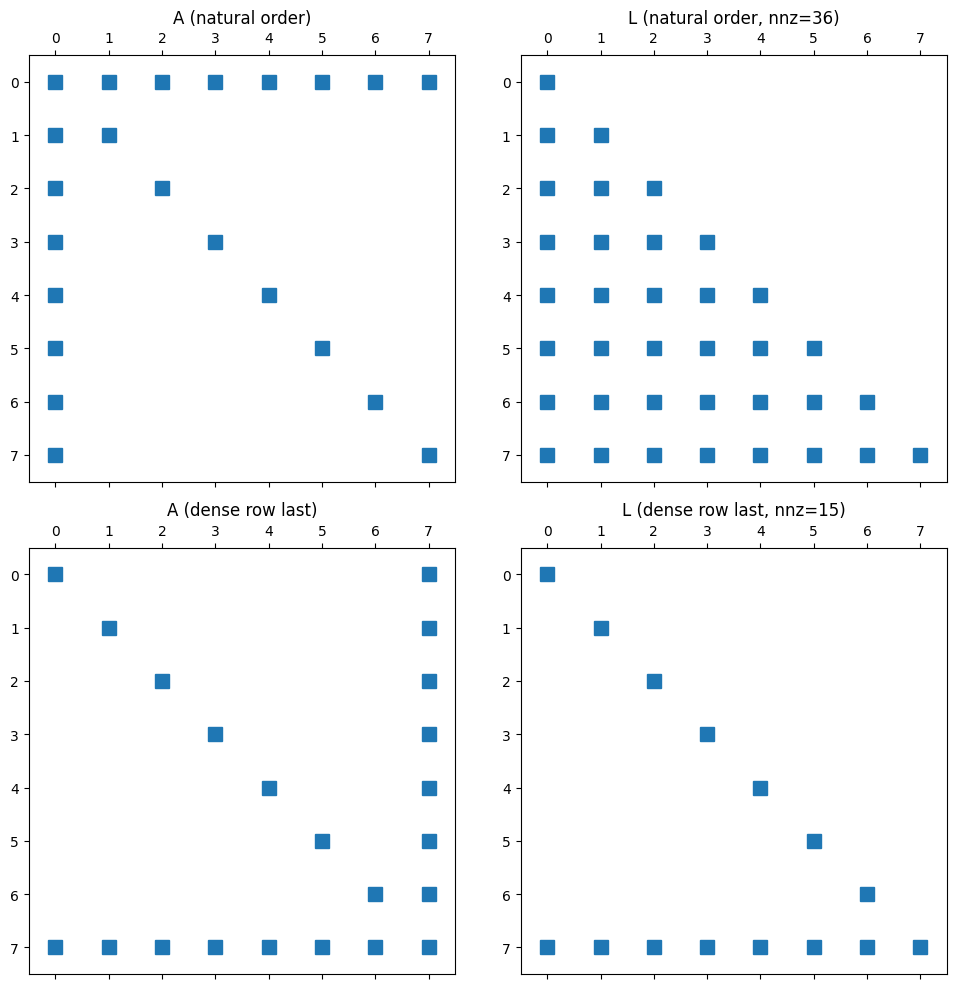


Moving the dense row to the end reduced fill from 36 to 15 entries!


In [3]:
from scipy.linalg import lu as scipy_lu

# Factor with natural ordering
# Simple LDL^T (this matrix is positive definite, so no pivoting needed)
def simple_cholesky_count(A):
    """Cholesky factor and count fill-in."""
    n = A.shape[0]
    L = np.linalg.cholesky(A)
    nnz_L = np.count_nonzero(np.abs(L) > 1e-12)
    return L, nnz_L

L_natural, nnz_natural = simple_cholesky_count(A)

# Reverse ordering: move the dense row/column to the END
perm = list(range(1, n)) + [0]
P = np.eye(n)[perm]
A_reordered = P @ A @ P.T
L_reordered, nnz_reordered = simple_cholesky_count(A_reordered)

print(f"Natural order:  nnz(L) = {nnz_natural}")
print(f"Reversed order: nnz(L) = {nnz_reordered}")

fig, axes = plt.subplots(2, 2, figsize=(10, 10))

axes[0, 0].spy(A, markersize=10)
axes[0, 0].set_title("A (natural order)")

axes[0, 1].spy(L_natural, markersize=10)
axes[0, 1].set_title(f"L (natural order, nnz={nnz_natural})")

axes[1, 0].spy(A_reordered, markersize=10)
axes[1, 0].set_title("A (dense row last)")

axes[1, 1].spy(L_reordered, markersize=10)
axes[1, 1].set_title(f"L (dense row last, nnz={nnz_reordered})")

plt.tight_layout()
plt.show()

print(f"\nMoving the dense row to the end reduced fill from {nnz_natural} to {nnz_reordered} entries!")

## The Key Insight

When we eliminate a variable (column $k$), we connect all its neighbors to each other. If column $k$ has $d$ nonzeros below the diagonal, elimination creates up to $\binom{d}{2}$ new fill entries.

**Rule of thumb:** Eliminate nodes with few connections first, save the heavily-connected nodes for last.

## Approximate Minimum Degree (AMD)

AMD is the standard fill-reducing ordering algorithm used in virtually all sparse solvers (including rmumps). It's a greedy heuristic:

1. Build the **adjacency graph** of $A$ (nodes = variables, edges = nonzero off-diagonals)
2. At each step, eliminate the node with the fewest remaining neighbors (**minimum degree**)
3. Update the graph: merge the eliminated node's neighbors (they're now connected to each other)

The "approximate" part: we use upper bounds on the degree to avoid expensive exact degree computation.

In [4]:
def minimum_degree_ordering(A):
    """Compute a minimum degree ordering (exact, not approximate).
    
    This is the simple/slow version for educational purposes.
    Real AMD uses approximations to be much faster.
    
    Returns: permutation array.
    """
    n = A.shape[0]
    
    # Build adjacency sets
    adj = [set() for _ in range(n)]
    for i in range(n):
        for j in range(n):
            if i != j and abs(A[i, j]) > 1e-15:
                adj[i].add(j)
    
    eliminated = set()
    perm = []
    
    for step in range(n):
        # Find the non-eliminated node with minimum degree
        min_deg = n + 1
        best = -1
        for i in range(n):
            if i not in eliminated:
                deg = len(adj[i] - eliminated)
                if deg < min_deg:
                    min_deg = deg
                    best = i
        
        perm.append(best)
        eliminated.add(best)
        
        # Connect all remaining neighbors of 'best' to each other (fill-in)
        neighbors = adj[best] - eliminated
        for u in neighbors:
            for v in neighbors:
                if u != v:
                    adj[u].add(v)
                    adj[v].add(u)
    
    return np.array(perm)

In [5]:
# Apply minimum degree to the arrow matrix
perm_md = minimum_degree_ordering(A)
print(f"Minimum degree order: {perm_md}")
print(f"(Notice: node 0 (the dense row) is eliminated LAST!)")

P_md = np.eye(n)[perm_md]
A_md = P_md @ A @ P_md.T
L_md, nnz_md = simple_cholesky_count(A_md)

print(f"\nMinimum degree order: nnz(L) = {nnz_md}")
print(f"Natural order:        nnz(L) = {nnz_natural}")

Minimum degree order: [1 2 3 4 5 6 0 7]
(Notice: node 0 (the dense row) is eliminated LAST!)

Minimum degree order: nnz(L) = 15
Natural order:        nnz(L) = 36


## AMD on a Larger Problem

Let's see the impact on a 2D Laplacian.

In [6]:
from scipy import sparse
from scipy.sparse.linalg import splu

def laplacian_2d_scipy(m):
    """Build 2D Laplacian as a scipy sparse matrix."""
    n = m * m
    rows, cols, vals = [], [], []
    for ix in range(m):
        for iy in range(m):
            row = ix * m + iy
            rows.append(row); cols.append(row); vals.append(4.0)
            if ix > 0:     rows.append(row); cols.append((ix-1)*m+iy); vals.append(-1.0)
            if ix < m-1:   rows.append(row); cols.append((ix+1)*m+iy); vals.append(-1.0)
            if iy > 0:     rows.append(row); cols.append(ix*m+(iy-1)); vals.append(-1.0)
            if iy < m-1:   rows.append(row); cols.append(ix*m+(iy+1)); vals.append(-1.0)
    return sparse.csc_matrix((vals, (rows, cols)), shape=(n, n))


results = []
for m in [10, 20, 30, 50]:
    n = m * m
    A = laplacian_2d_scipy(m)
    
    lu_nat = splu(A, permc_spec='NATURAL')
    lu_amd = splu(A, permc_spec='MMD_ATA')
    
    nnz_A = A.nnz
    nnz_nat = lu_nat.L.nnz + lu_nat.U.nnz
    nnz_amd = lu_amd.L.nnz + lu_amd.U.nnz
    
    results.append((m, n, nnz_A, nnz_nat, nnz_amd))
    print(f"m={m:>3}  n={n:>5}  nnz(A)={nnz_A:>7}  "
          f"nnz(L+U) natural={nnz_nat:>9}  AMD={nnz_amd:>9}  "
          f"reduction={nnz_nat/nnz_amd:.1f}x")

m= 10  n=  100  nnz(A)=    460  nnz(L+U) natural=     2018  AMD=     1486  reduction=1.4x
m= 20  n=  400  nnz(A)=   1920  nnz(L+U) natural=    16038  AMD=    10098  reduction=1.6x
m= 30  n=  900  nnz(A)=   4380  nnz(L+U) natural=    54058  AMD=    28832  reduction=1.9x
m= 50  n= 2500  nnz(A)=  12300  nnz(L+U) natural=   250098  AMD=   108546  reduction=2.3x


## The Elimination Tree

The **elimination tree** (etree) is the fundamental data structure for sparse factorization. It encodes the **dependency structure** of the elimination process.

### Definition

For a symmetric positive definite matrix $A$ with Cholesky factor $L$:
- Each column $j$ is a node in the tree
- The parent of node $j$ is $\text{parent}(j) = \min\{i > j : l_{ij} \neq 0\}$
- In other words: the parent of column $j$ is the row index of the **first subdiagonal nonzero** in column $j$ of $L$

### Key Property

Column $j$ of $L$ only depends on its **descendants** in the etree. This means:
- Columns on independent branches can be factored **in parallel**
- The tree reveals the minimum possible sequential depth of the factorization

### Computing the Elimination Tree

We can compute the etree from the sparsity pattern of $A$ alone — no numeric factorization needed!

In [7]:
def compute_etree(A_sparse):
    """Compute the elimination tree from a symmetric sparse matrix.
    
    Uses the row-subtree algorithm (Liu, 1990).
    
    Parameters:
        A_sparse: scipy sparse matrix (symmetric)
    
    Returns:
        parent: array where parent[j] = parent of node j (-1 for root)
    """
    n = A_sparse.shape[0]
    A_csc = sparse.csc_matrix(A_sparse)
    parent = np.full(n, -1, dtype=int)
    ancestor = np.arange(n, dtype=int)  # for path compression
    
    def find(i):
        """Find root with path compression."""
        r = i
        while ancestor[r] != r:
            r = ancestor[r]
        # Path compression
        while ancestor[i] != r:
            ancestor[i], i = r, ancestor[i]
        return r
    
    for k in range(n):
        # Process each row index i in column k (with i < k)
        start = A_csc.indptr[k]
        end = A_csc.indptr[k + 1]
        for idx in range(start, end):
            i = A_csc.indices[idx]
            if i >= k:
                continue
            r = find(i)
            if r != k:
                parent[r] = k
                ancestor[r] = k
    
    return parent

In [8]:
# Compute and visualize the etree for a small Laplacian
m = 4
n = m * m
A = laplacian_2d_scipy(m)

parent = compute_etree(A)

print(f"Elimination tree for {m}x{m} Laplacian (n={n}):")
print(f"Node:   {list(range(n))}")
print(f"Parent: {list(parent)}")

# Compute depth of each node (for visualization)
depth = np.zeros(n, dtype=int)
for j in range(n):
    node = j
    d = 0
    while parent[node] != -1:
        d += 1
        node = parent[node]
    depth[j] = d

# Count children for each node
children = [[] for _ in range(n)]
roots = []
for j in range(n):
    if parent[j] == -1:
        roots.append(j)
    else:
        children[parent[j]].append(j)

print(f"\nRoot(s): {roots}")
print(f"Tree depth: {max(depth)}")

# Count leaves (no children) — these can all be factored in parallel
leaves = [j for j in range(n) if len(children[j]) == 0]
print(f"Leaves (parallelizable): {len(leaves)} out of {n} nodes")

Elimination tree for 4x4 Laplacian (n=16):
Node:   [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
Parent: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(-1)]

Root(s): [15]
Tree depth: 15
Leaves (parallelizable): 1 out of 16 nodes


## Supernodes: Grouping Columns

Consecutive columns in $L$ often have the **same sparsity pattern** (same set of nonzero row indices). These can be grouped into **supernodes** and factored as dense blocks.

This is the key to performance:
- Dense blocks use BLAS Level-3 (matrix-matrix multiply)
- BLAS Level-3 gets close to peak hardware speed
- Individual column operations (BLAS Level-2) are memory-bound and slow

In [9]:
def find_supernodes(parent, A_sparse):
    """Identify supernodes: groups of consecutive columns with the same pattern.
    
    A simple heuristic: column j+1 is in the same supernode as j if:
    1. parent[j] == j+1 (j's only child in the etree is j+1)
    2. The structural patterns match (same nonzero rows below the diagonal)
    
    Returns list of supernodes, each a list of column indices.
    """
    n = len(parent)
    
    # Count children
    n_children = np.zeros(n, dtype=int)
    for j in range(n):
        if parent[j] != -1:
            n_children[parent[j]] += 1
    
    supernodes = []
    current = [0]
    
    for j in range(1, n):
        prev = current[-1]
        # Check if j continues the same supernode
        if parent[prev] == j and n_children[j] == 1:
            current.append(j)
        else:
            supernodes.append(current)
            current = [j]
    supernodes.append(current)
    
    return supernodes


m = 10
n = m * m
A = laplacian_2d_scipy(m)
parent = compute_etree(A)
supernodes = find_supernodes(parent, A)

sizes = [len(s) for s in supernodes]
print(f"{m}x{m} Laplacian (n={n}):")
print(f"  Supernodes: {len(supernodes)}")
print(f"  Supernode sizes: min={min(sizes)}, max={max(sizes)}, avg={np.mean(sizes):.1f}")
print(f"  Size distribution: {dict(zip(*np.unique(sizes, return_counts=True)))}")

10x10 Laplacian (n=100):
  Supernodes: 1
  Supernode sizes: min=100, max=100, avg=100.0
  Size distribution: {np.int64(100): np.int64(1)}


## Symbolic Factorization

A remarkable fact: we can determine the **exact sparsity pattern** of $L$ from the sparsity pattern of $A$ and the elimination tree — without doing any floating-point arithmetic.

This is called **symbolic factorization** and it determines:
- How much memory to allocate for $L$
- Which operations to perform during numeric factorization
- The supernode structure

Symbolic factorization is done **once** when the sparsity pattern is known. The expensive numeric factorization can then be repeated efficiently for different numerical values with the same pattern — exactly what happens in interior point methods where the KKT structure stays fixed across iterations.

In [10]:
def symbolic_factor(A_sparse, parent):
    """Predict the nonzero pattern of L from the etree.
    
    For each column j: the nonzero rows in L[:,j] are the
    ancestors of j in the etree that are reachable through
    the original nonzero pattern.
    """
    n = A_sparse.shape[0]
    A_csc = sparse.csc_matrix(A_sparse)
    
    # For each column, compute the row indices of L
    L_pattern = [set() for _ in range(n)]
    
    for j in range(n):
        # Start with the original nonzeros in column j (below diagonal)
        start = A_csc.indptr[j]
        end = A_csc.indptr[j + 1]
        for idx in range(start, end):
            i = A_csc.indices[idx]
            if i > j:
                L_pattern[j].add(i)
        
        # Add fill from children's patterns
        for c in range(j):
            if parent[c] == j:
                # Child c contributes: its L pattern minus {j}
                for row in L_pattern[c]:
                    if row > j:
                        L_pattern[j].add(row)
    
    total_nnz = n  # diagonal
    for j in range(n):
        total_nnz += len(L_pattern[j])
    
    return L_pattern, total_nnz


# Compare symbolic prediction with actual factorization
m = 10
A = laplacian_2d_scipy(m)
parent = compute_etree(A)

L_pattern, predicted_nnz = symbolic_factor(A, parent)

# Actual factorization
lu = splu(A, permc_spec='NATURAL')
actual_nnz = lu.L.nnz

print(f"Symbolic prediction: nnz(L) = {predicted_nnz}")
print(f"Actual nnz(L):               {actual_nnz}")
print(f"(Small differences are expected due to LU vs LDL^T and numerical cancellation)")

Symbolic prediction: nnz(L) = 1009
Actual nnz(L):               1009
(Small differences are expected due to LU vs LDL^T and numerical cancellation)


## Putting It Together: The Sparse Factorization Pipeline

Here's the complete pipeline from problem to solution:

```
1. ASSEMBLY (COO)
   Build matrix in triplet format
        ↓
2. CONVERSION (COO → CSC)
   Compress to column format, sum duplicates
        ↓
3. ORDERING (AMD)
   Find fill-reducing permutation P
        ↓
4. SYMBOLIC FACTORIZATION
   Compute elimination tree, supernodes,
   predict structure of L (done ONCE)
        ↓
5. NUMERIC FACTORIZATION
   Compute actual values: PAP^T = LDL^T
   (repeated at each optimization iteration)
        ↓
6. SOLVE
   Forward/backward substitution + refinement
```

Steps 1-4 are the **analyze phase** (done once).
Steps 5-6 are the **factor-solve phase** (repeated).

This separation is exactly what rmumps implements:
- `RMumps::analyze()` does steps 2-4
- `RMumps::factor()` does step 5
- `RMumps::solve()` does step 6

In [11]:
import time

# Demonstrate the analyze-once, factor-many pattern
m = 50
n = m * m
A_base = laplacian_2d_scipy(m)

# "Analyze" phase: ordering + symbolic
t0 = time.perf_counter()
parent = compute_etree(A_base)
supernodes = find_supernodes(parent, A_base)
L_pattern, predicted_nnz = symbolic_factor(A_base, parent)
t_analyze = time.perf_counter() - t0

# "Factor" phase: numeric factorization (simulate 10 iterations)
t0 = time.perf_counter()
for iteration in range(10):
    # In optimization, the values change but the pattern stays the same
    scale = 1.0 + 0.1 * iteration
    A_iter = A_base * scale
    lu = splu(A_iter, permc_spec='NATURAL')
t_factor = (time.perf_counter() - t0) / 10

# "Solve" phase
b = np.random.randn(n)
t0 = time.perf_counter()
for _ in range(100):
    x = lu.solve(b)
t_solve = (time.perf_counter() - t0) / 100

print(f"Problem size: n = {n}")
print(f"Analyze (once):       {t_analyze*1000:.1f} ms")
print(f"Factor (per iter):    {t_factor*1000:.1f} ms")
print(f"Solve (per RHS):      {t_solve*1000:.2f} ms")
print(f"\nFactor/Solve ratio:   {t_factor/t_solve:.0f}x")
print(f"Supernodes: {len(supernodes)} (from {n} columns)")

Problem size: n = 2500
Analyze (once):       443.3 ms
Factor (per iter):    11.6 ms
Solve (per RHS):      0.32 ms

Factor/Solve ratio:   36x
Supernodes: 1 (from 2500 columns)


## What We've Learned

1. **Fill-reducing orderings** (AMD) minimize new nonzeros in the factor by eliminating low-degree nodes first
2. The **elimination tree** encodes dependencies between columns — independent branches can be processed in parallel
3. **Supernodes** group columns with the same pattern for efficient dense block operations
4. **Symbolic factorization** predicts the exact structure of $L$ from the pattern of $A$ — no numerics needed
5. The **analyze-factor-solve** pipeline lets us reuse symbolic work across iterations

## What's Next

In Note 6, we put everything together with the **multifrontal method** — the algorithm that rmumps actually implements. It organizes the factorization as a tree of dense operations on **frontal matrices**, combining fill-reducing orderings, supernodal grouping, and the elimination tree into a single elegant framework.

---

*This is Note 5 in a series building from basic Gaussian elimination to the multifrontal sparse solver used in [ripopt](https://github.com/jkitchin/ripopt).*